## PRCP-1006-HomeLoanDef

### Understanding the Objective

   Building a model to predict factors / customer segments that are eligible for taking loan

### Data Loading and Overview

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [3]:
#Importing the Data Set

data = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\DATAMITES\PROJECT\Homeloan\Data\application_train.csv")
bureau = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\DATAMITES\PROJECT\Homeloan\Data\bureau.csv")
bureau_balance  = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\DATAMITES\PROJECT\Homeloan\Data\bureau_balance.csv")
credit_card_balance = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\DATAMITES\PROJECT\Homeloan\Data\credit_card_balance.csv")
previous_application = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\DATAMITES\PROJECT\Homeloan\Data\previous_application.csv")

In [4]:
installments_payments = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\DATAMITES\PROJECT\Homeloan\Data\installments_payments.csv")

In [5]:
datasets = {
    "application_train": data,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "credit_card_balance": credit_card_balance,
    "installments_payments": installments_payments,
    "previous_application": previous_application
}

for name, df in datasets.items():
    print(f"{name:}: {df.shape}")

application_train: (307511, 122)
bureau: (1716428, 17)
bureau_balance: (27299925, 3)
credit_card_balance: (3840312, 23)
installments_payments: (13605401, 8)
previous_application: (1670214, 37)


In [6]:
for name, df in datasets.items():
    print(name.upper())
    display(df.head(5))

APPLICATION_TRAIN


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


BUREAU


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


BUREAU_BALANCE


...

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


INSTALLMENTS_PAYMENTS


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


PREVIOUS_APPLICATION


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


| Dataset Name              | Rows       | Columns | Description                                                                                                                                                  |
| ------------------------- | ---------- | ------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **application_train**     | 307,511    | 122     | Main dataset containing applicant information and target variable (`TARGET`: 1 = Defaulter, 0 = Non-defaulter). Each record represents one loan application. |
| **bureau**                | 1,717,428  | 17      | Contains information about previous credits of clients taken from other financial institutions. Multiple records may exist for each applicant.               |
| **bureau_balance**        | 27,299,925 | 3       | Provides monthly balance data for each credit record in the Bureau dataset, offering detailed time-series information.                                       |
| **previous_application**  | 1,670,214  | 37      | Records all previous loan applications made by clients before the current one.                                                                               |
| **credit_card_balance**   | 3,840,312  | 23      | Tracks monthly credit card balance information for applicants.                                                                                               |
| **installments_payments** | 13,605,401 | 8       | Contains historical payment data for installments of previous loans.  

* `application_train` is applicant-level (one record per loan).
* Other datasets such as `bureau`, `previous_application`, and balance datasets contain multiple records per applicant, representing time-series or transactional information.
* Datasets like `bureau_balance`, `installments_payments` have millions of rows.
* **Relationship Mapping**
   * The common key across datasets is `SK_ID_CURR`.
   * Other relationship keys include `SK_ID_BUREAU` (linking `bureau` and `bureau_balance`) and `SK_ID_PREV` (linking `previous_application` with other balance datasets).
   * Proper joining and aggregation strategies are essential to prevent data duplication and maintain referential integrity.

### Exploring Data 

In [7]:
data.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [8]:
data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [9]:
data.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [10]:
data.nunique().sort_values(ascending=False).head(15)

SK_ID_CURR           307511
EXT_SOURCE_2         119831
EXT_SOURCE_1         114584
DAYS_BIRTH            17460
DAYS_REGISTRATION     15688
AMT_ANNUITY           13672
DAYS_EMPLOYED         12574
DAYS_ID_PUBLISH        6168
AMT_CREDIT             5603
LIVINGAREA_MODE        5301
LIVINGAREA_MEDI        5281
LIVINGAREA_AVG         5199
TOTALAREA_MODE         5116
BASEMENTAREA_MODE      3841
BASEMENTAREA_AVG       3780
dtype: int64

In [11]:
for name, df in datasets.items():
    print(f"\nDataset: {name}")
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    missing_data = pd.DataFrame({
        'Missing Values': missing,
        'Missing %': missing_percent
    })
    missing_data = missing_data[missing_data['Missing Values'] > 0] \
                   .sort_values(by='Missing %', ascending=False)
    print(missing_data.head(15))
    print("-" * 60)


Dataset: application_train
                          Missing Values  Missing %
COMMONAREA_MEDI                   214865  69.872297
COMMONAREA_MODE                   214865  69.872297
COMMONAREA_AVG                    214865  69.872297
NONLIVINGAPARTMENTS_MODE          213514  69.432963
NONLIVINGAPARTMENTS_MEDI          213514  69.432963
NONLIVINGAPARTMENTS_AVG           213514  69.432963
FONDKAPREMONT_MODE                210295  68.386172
LIVINGAPARTMENTS_AVG              210199  68.354953
LIVINGAPARTMENTS_MEDI             210199  68.354953
LIVINGAPARTMENTS_MODE             210199  68.354953
FLOORSMIN_MEDI                    208642  67.848630
FLOORSMIN_MODE                    208642  67.848630
FLOORSMIN_AVG                     208642  67.848630
YEARS_BUILD_MODE                  204488  66.497784
YEARS_BUILD_MEDI                  204488  66.497784
------------------------------------------------------------

Dataset: bureau
                        Missing Values  Missing %
AMT_ANNUITY 

### Feature Engineering and Dataset Aggregation

In [12]:
data = datasets['application_train']

data['CREDIT_INCOME_RATIO'] = data['AMT_CREDIT'] / (data['AMT_INCOME_TOTAL'] + 1)
data['ANNUITY_INCOME_RATIO'] = data['AMT_ANNUITY'] / (data['AMT_INCOME_TOTAL'] + 1)
data['CREDIT_TERM'] = data['AMT_CREDIT'] / (data['AMT_ANNUITY'] + 1)
data['GOODS_CREDIT_RATIO'] = data['AMT_GOODS_PRICE'] / (data['AMT_CREDIT'] + 1)

In [13]:
bb_agg = bureau_balance.groupby('SK_ID_BUREAU').agg({
    'MONTHS_BALANCE': ['min', 'max', 'mean'],
    'STATUS': 'nunique'
})
bb_agg.columns = ['_'.join(col) for col in bb_agg.columns]

bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')

bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': ['mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['max'],
    'DAYS_CREDIT': ['min', 'max', 'mean']
})
bureau_agg.columns = ['BUREAU_' + '_'.join(col) for col in bureau_agg.columns]

data = data.merge(bureau_agg, on='SK_ID_CURR', how='left')


In [14]:
prev_agg = previous_application.groupby('SK_ID_CURR').agg({
    'AMT_APPLICATION': ['mean', 'max'],
    'AMT_CREDIT': ['mean', 'max'],
    'DAYS_DECISION': ['mean', 'max'],
    'NAME_CONTRACT_STATUS': lambda x: (x == 'Refused').sum()
})
prev_agg.columns = ['PREV_' + '_'.join(col) for col in prev_agg.columns]

data = data.merge(prev_agg, on='SK_ID_CURR', how='left')


In [15]:
installments_payments['PAYMENT_DIFF'] = (
    installments_payments['AMT_PAYMENT'] -
    installments_payments['AMT_INSTALMENT']
)

installments_payments['LATE_PAYMENT'] = (
    installments_payments['DAYS_ENTRY_PAYMENT'] >
    installments_payments['DAYS_INSTALMENT']
).astype(int)

inst_agg = installments_payments.groupby('SK_ID_CURR').agg({
    'PAYMENT_DIFF': ['mean', 'min'],
    'LATE_PAYMENT': ['mean', 'sum'],
    'AMT_PAYMENT': ['mean', 'sum']
})
inst_agg.columns = ['INS_' + '_'.join(col) for col in inst_agg.columns]

data = data.merge(inst_agg, on='SK_ID_CURR', how='left')

In [16]:
cc_agg = credit_card_balance.groupby('SK_ID_CURR').agg({
    'AMT_BALANCE': ['mean', 'max'],
    'AMT_DRAWINGS_CURRENT': ['sum', 'max'],
    'CNT_DRAWINGS_CURRENT': 'sum',
    'SK_DPD': 'max'
})
cc_agg.columns = ['CARD_' + '_'.join(col) for col in cc_agg.columns]

data = data.merge(cc_agg, on='SK_ID_CURR', how='left')


In [17]:
print("Final dataset shape:", data.shape)

Final dataset shape: (307511, 153)


- To enrich the predictive capability of the model, multiple related datasets were aggregated at the customer level using SK_ID_CURR. Summary statistics such as mean, sum, maximum, and minimum were derived from historical loan applications, installment payment behavior, credit card usage, and bureau records. Additionally, domain-specific financial ratios such as credit-to-income, annuity-to-income, loan tenure, and goods-to-credit ratios were engineered to capture repayment capacity and credit risk. These aggregated and engineered features provide a comprehensive representation of each applicant’s financial behavior and credit history.

### Handling Null Values

In [18]:
data.isnull().sum()

SK_ID_CURR                            0
TARGET                                0
NAME_CONTRACT_TYPE                    0
CODE_GENDER                           0
FLAG_OWN_CAR                          0
                                  ...  
CARD_AMT_BALANCE_max             220606
CARD_AMT_DRAWINGS_CURRENT_sum    220606
CARD_AMT_DRAWINGS_CURRENT_max    220606
CARD_CNT_DRAWINGS_CURRENT_sum    220606
CARD_SK_DPD_max                  220606
Length: 153, dtype: int64

In [19]:
num_cols = data.select_dtypes(include=['number']).columns
num_cols = num_cols.drop('TARGET')

data[num_cols] = data[num_cols].fillna(0)

cat_cols = data.select_dtypes(include=['object']).columns
data[cat_cols] = data[cat_cols].fillna('Unknown')


In [20]:
data.isnull().sum().sum()

np.int64(0)

In [21]:
data['SK_ID_CURR'].is_unique

True

- After merging multiple auxiliary datasets (bureau, previous applications, credit card balance, installments, etc.), a significant number of numerical features contained missing values. These missing values primarily occurred in aggregated features such as sums, means, and maximums derived from transactional histories.

- In the context of credit risk analysis, a missing value in such aggregated numerical features does not indicate unknown information, but rather reflects the absence of historical activity for that customer (e.g., no credit card usage, no installment payments, or no previous loans).

- Therefore, numerical missing values were imputed using zero (0), which semantically represents no transaction, no balance, or no past record. This approach preserves the true business meaning of the data and avoids introducing artificial patterns that could arise from statistical imputations such as mean or median replacement.

- Categorical features were imputed with an "Unknown" category to retain missing information without discarding records or introducing bias.The target variable was explicitly excluded from imputation to prevent data leakage and maintain label integrity.

- A post-imputation validation confirmed that no missing values remained in the dataset. Additionally, the uniqueness of the customer identifier (SK_ID_CURR) was verified, ensuring that each row represents a distinct applicant and preventing duplicate-record bias in model training.

### Descriptive Statistics

In [22]:
pd.set_option('display.max_rows', None)
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.687979e+05,2.371231e+05,2.565000e+04,112500.000000,147150.000000,2.025000e+05,1.170000e+08
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307511.0,2.710752e+04,1.449444e+04,0.000000e+00,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307511.0,5.379095e+05,3.696338e+05,0.000000e+00,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,307511.0,6.381505e+04,1.412758e+05,-1.791200e+04,-2760.000000,-1213.000000,-2.890000e+02,3.652430e+05


### Target Distribution

In [23]:
target = data['TARGET'].value_counts()
target_percent = 100 * data['TARGET'].value_counts()/ len(data['TARGET'])

target_table = pd.DataFrame({
    'Target Values': target,
    'Target %': target_percent, 
})

target_table 

,Target Values,Target %
TARGET,,
0,282686,91.927118
1,24825,8.072882


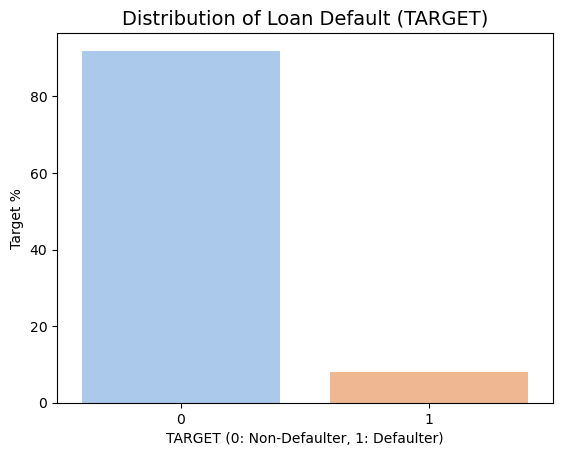

In [24]:
sns.barplot(
    x=target_percent.index,
    y=target_percent.values,
    hue=target_percent.index,  
    palette='pastel',
    legend=False
)

plt.title('Distribution of Loan Default (TARGET)', fontsize=14)
plt.xlabel('TARGET (0: Non-Defaulter, 1: Defaulter)')
plt.ylabel('Target %')
plt.show()

Observations
* approximately **91.9% of applicants are non-defaulters** (TARGET = 0), while only **8.1% are defaulters** (TARGET = 1).
* This shows a highly **imbalanced dataset**, meaning that the model could easily predict most loans as “non-default” and still achieve high accuracy, but **perform poorly in identifying true defaulters**.
* To address this, techniques such as **SMOTE (Synthetic Minority Oversampling Technique**, **undersampling**, or **class-weight adjustments** can be applied during model training to ensure balanced learning and fair model performance across both classes.

#### Distribution of Applicant Income

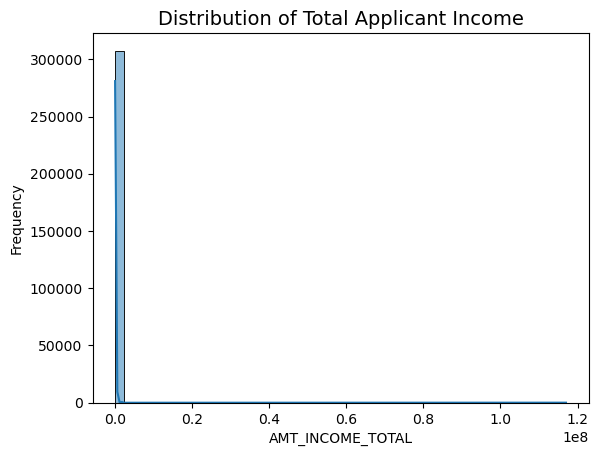

In [25]:
sns.histplot(data['AMT_INCOME_TOTAL'], bins=50, kde=True)
plt.title('Distribution of Total Applicant Income', fontsize=14)
plt.xlabel('AMT_INCOME_TOTAL')
plt.ylabel('Frequency')
plt.show()

- The distribution of total applicant income is highly right-skewed, with the majority of applicants concentrated in the lower income range.

- A small number of applicants have very high incomes, creating a long tail and extreme values in the distribution.

- This skewness indicates the presence of income outliers, which can disproportionately influence models sensitive to scale.

- To better capture underlying patterns, a log transformation of income is appropriate and helps stabilize variance for modeling.

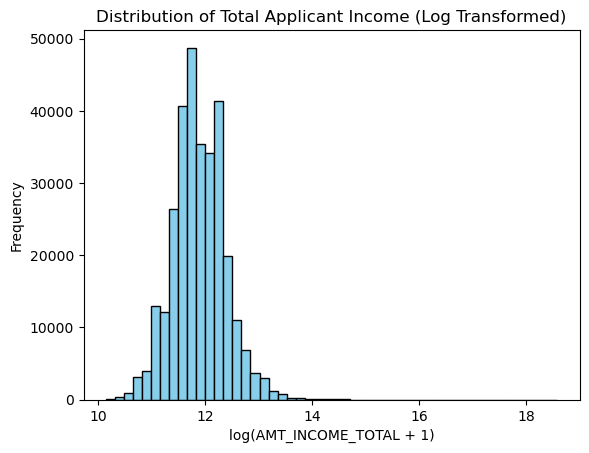

In [26]:
plt.hist(np.log1p(data['AMT_INCOME_TOTAL']), bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Applicant Income (Log Transformed)')
plt.xlabel('log(AMT_INCOME_TOTAL + 1)')
plt.ylabel('Frequency')
plt.show()

- Log transformed graph helps in understanding the differences between low and middle-income groups.

#### Loan Amount Distribution

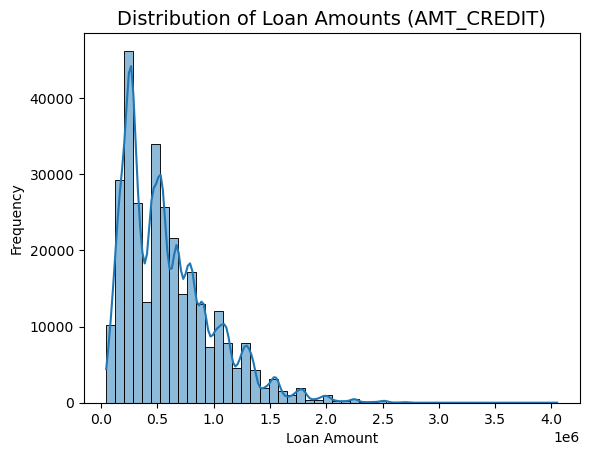

In [27]:
sns.histplot(data['AMT_CREDIT'], bins=50, kde=True)
plt.title('Distribution of Loan Amounts (AMT_CREDIT)', fontsize=14)
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

- The loan amount distribution is right-skewed, with most applicants requesting moderate loan amounts.

- A smaller number of applicants request very high loan amounts, resulting in a long tail in the distribution.

- The presence of extreme loan values indicates heterogeneity in borrowing behavior across applicants.

- This skewed pattern suggests that loan amount may have a non-linear relationship with default risk and should be carefully considered during modeling.

#### Age Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_13384\4046696354.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['AGE'] = abs(data['DAYS_BIRTH']) / 365


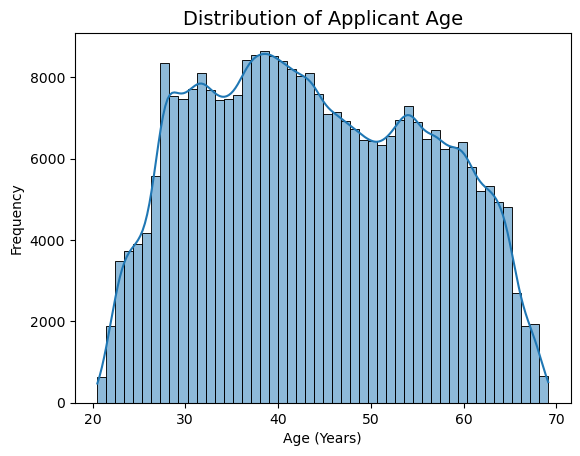

In [39]:
data['AGE'] = abs(data['DAYS_BIRTH']) / 365

sns.histplot(data['AGE'], bins=50, kde=True)
plt.title('Distribution of Applicant Age', fontsize=14)
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.savefig("Distribution of Applicant Age.png")
plt.show()

- The majority of applicants are between 25 and 45 years old, with a steady decline toward older age groups.
- Very few applicants are above 60.
- Younger applicants may represent higher loan activity.

#### Gender Distribution

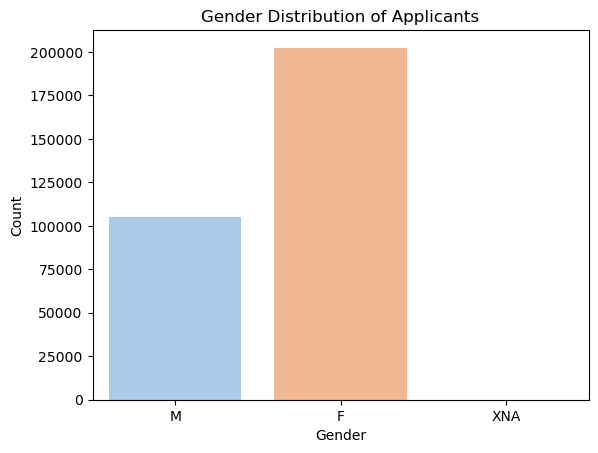

In [28]:
sns.countplot(
    x='CODE_GENDER',
    data=data,
    hue='CODE_GENDER', 
    palette='pastel',
    legend=False
)

plt.title('Gender Distribution of Applicants')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig("Gender Distribution of Applicants.png")
plt.show()

- The applicant pool is female-dominated, with a significantly higher number of female applicants compared to male applicants.

- Male applicants represent a smaller but substantial portion of the dataset.

- The XNA category is negligible, indicating minimal missing or undefined gender information.

#### Education Type

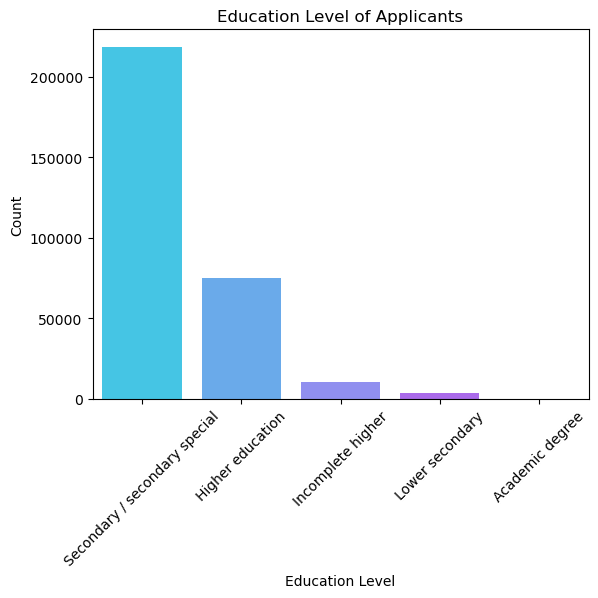

In [29]:
sns.countplot(
        x='NAME_EDUCATION_TYPE',
        data=data,
        order=data['NAME_EDUCATION_TYPE'].value_counts().index,
        hue='NAME_EDUCATION_TYPE', 
        palette='cool',
        legend=False
    )
    
plt.title('Education Level of Applicants')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

- Most applicants have Secondary / Secondary Special education, indicating a predominantly mid-education applicant base.

- Applicants with Higher Education form the second-largest group, suggesting education level may influence loan eligibility.

- Very few applicants belong to lower secondary or academic degree categories, making them less influential in modeling.

#### Housing Type

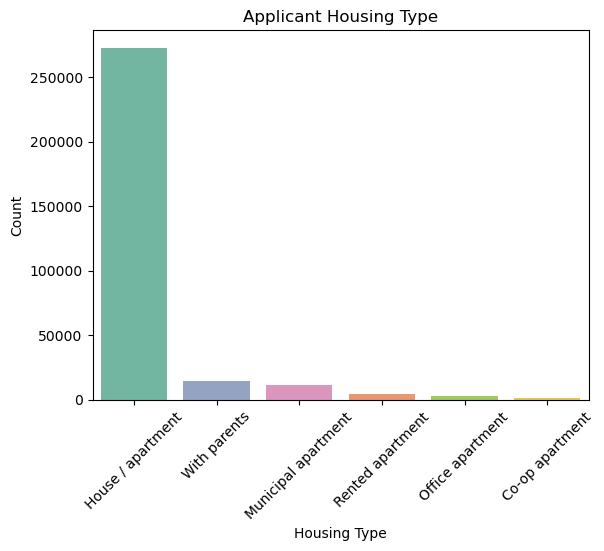

In [30]:
sns.countplot(
    x='NAME_HOUSING_TYPE',
    data=data,
    order=data['NAME_HOUSING_TYPE'].value_counts().index,
    hue='NAME_HOUSING_TYPE',   
    palette='Set2',
    legend=False
)

plt.title('Applicant Housing Type')
plt.xlabel('Housing Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


- Most applicants have Secondary / Secondary Special education, indicating a predominantly mid-education applicant base.

- Applicants with Higher Education form the second-largest group, suggesting education level may influence loan eligibility.

- Very few applicants belong to lower secondary or academic degree categories, making them less influential in modeling.

### Income vs Default

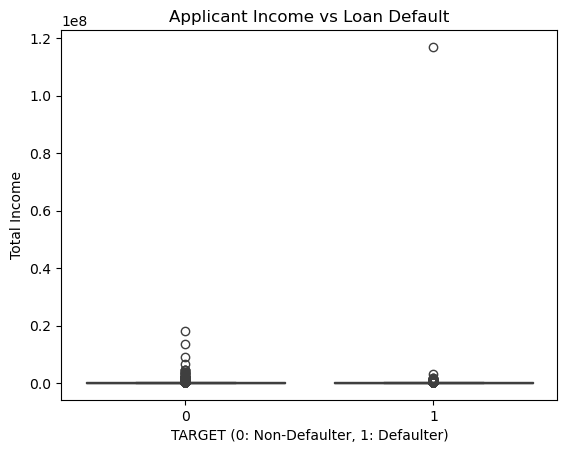

In [31]:
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=data)
plt.title('Applicant Income vs Loan Default')
plt.xlabel('TARGET (0: Non-Defaulter, 1: Defaulter)')
plt.ylabel('Total Income')
plt.show()

- Both defaulters and non-defaulters show significant income overlap, indicating income alone does not determine default.

- Extreme income outliers are present in both classes, which can distort interpretation without transformation.

- The wide spread highlights the need for feature combinations rather than relying on income alone.

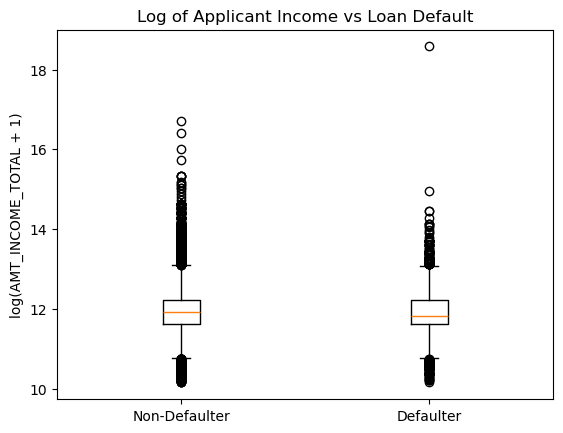

In [32]:
plt.boxplot([np.log1p(data[data['TARGET']==0]['AMT_INCOME_TOTAL']),
             np.log1p(data[data['TARGET']==1]['AMT_INCOME_TOTAL'])])
plt.xticks([1, 2], ['Non-Defaulter', 'Defaulter'])
plt.title('Log of Applicant Income vs Loan Default')
plt.ylabel('log(AMT_INCOME_TOTAL + 1)')
plt.show()

- After log transformation, income distributions of defaulters and non-defaulters become more comparable and interpretable.

- Defaulters tend to have a slightly lower median income compared to non-defaulters.

- Log transformation reduces outlier impact, making income a more reliable predictive feature.

In [33]:
# Create a new column for log-transformed income
data['LOG_AMT_INCOME_TOTAL'] = np.log1p(data['AMT_INCOME_TOTAL'])

# Group by TARGET and calculate summary statistics
summary = data.groupby('TARGET')['LOG_AMT_INCOME_TOTAL'].agg(
    Mean='mean',
    Median='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

# Calculate IQR
summary['IQR'] = summary['Q3'] - summary['Q1']

print(summary)

             Mean     Median         Q1       Q3       IQR
TARGET                                                    
0       11.911923  11.908347  11.630717  12.2185  0.587783
1       11.878753  11.813037  11.630717  12.2185  0.587783


C:\Users\User\AppData\Local\Temp\ipykernel_13384\2221377044.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['LOG_AMT_INCOME_TOTAL'] = np.log1p(data['AMT_INCOME_TOTAL'])


- Mean and median values for both classes are almost the same. This confirms no major income difference between defaulters and non-defaulters.
- IQR (interquartile range) is nearly identical for both, meaning income variation within each group is similar

### Loan Amount vs Default

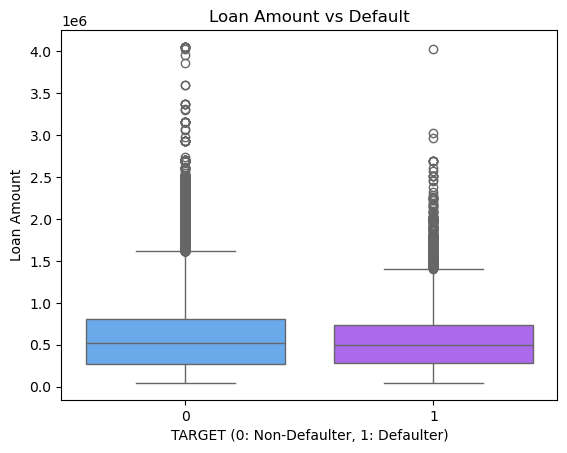

In [34]:
sns.boxplot(
    x='TARGET',
    y='AMT_CREDIT',
    data=data,
    hue='TARGET',        
    palette='cool',
    legend=False
)

plt.title('Loan Amount vs Default')
plt.xlabel('TARGET (0: Non-Defaulter, 1: Defaulter)')
plt.ylabel('Loan Amount')
plt.savefig('Loan Amount vs Default.png')
plt.show()

In [35]:
# Group by TARGET and calculate statistics for loan amount 
loan_summary = data.groupby('TARGET')['AMT_CREDIT'].agg(
    Mean='mean',
    Median='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

# Add IQR (Interquartile Range)
loan_summary['IQR'] = loan_summary['Q3'] - loan_summary['Q1']

print(loan_summary)

                 Mean    Median        Q1        Q3       IQR
TARGET                                                       
0       602648.282002  517788.0  270000.0  810000.0  540000.0
1       557778.527674  497520.0  284400.0  733315.5  448915.5


- Mean loan amount for defaulters is a bit lower than for non-defaulters.
- Similarly, the median shows that defaulters generally took smaller loans on average.
- The interquartile range (IQR) for both groups is close - This means both groups have similar variability in loan amounts.
- Loan amount alone doesn’t strongly differentiate defaulters from non-defaulters.

### Age vs Loan Default

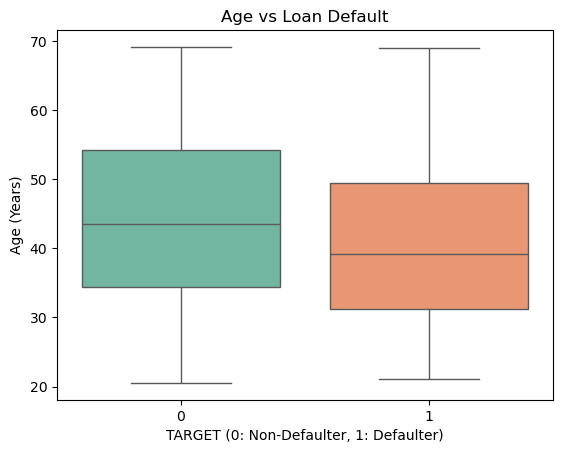

In [41]:
data['AGE'] = data['DAYS_BIRTH'].abs() / 365
sns.boxplot(
    x='TARGET',
    y='AGE',
    data=data,
    hue='TARGET',
    palette='Set2',
    legend=False
)

plt.title('Age vs Loan Default')
plt.xlabel('TARGET (0: Non-Defaulter, 1: Defaulter)')
plt.ylabel('Age (Years)')
plt.savefig('Age vs Loan Default.png')
plt.show()


- Defaulters tend to be slightly younger on average compared to non-defaulters.

- Non-defaulters show a higher median age, suggesting age may influence repayment stability.

- There is considerable overlap, indicating age alone is not a sole determinant of default.

### Gender vs Default Rate

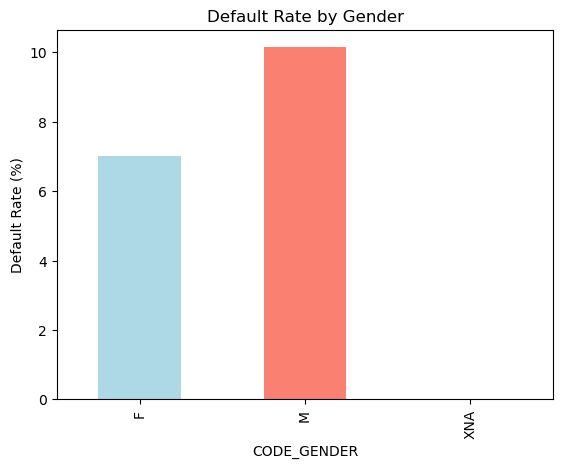

In [42]:
gender_default = data.groupby('CODE_GENDER')['TARGET'].mean() * 100
gender_default.plot(kind='bar', color=['lightblue','salmon'])
plt.title('Default Rate by Gender')
plt.ylabel('Default Rate (%)')
plt.show()

- Male applicants exhibit a higher default rate compared to female applicants.

- Female applicants show relatively better repayment behavior.

- The XNA category is negligible and does not impact analysis.

### Education vs Default

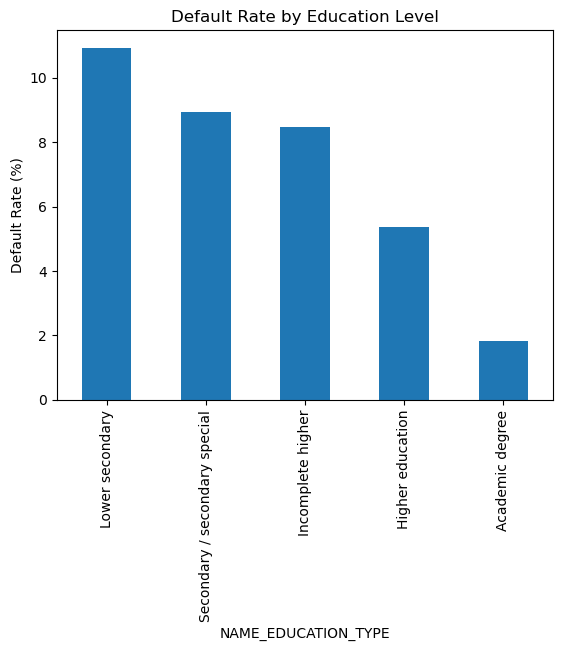

In [43]:
edu_default = data.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False) * 100
edu_default.plot(kind='bar')
plt.title('Default Rate by Education Level')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=90)
plt.show()

- Applicants with lower secondary education have the highest default rates.

- Default rates decrease as education level increases, indicating a negative relationship between education and default risk.

- Applicants with academic degrees show the lowest default rates, suggesting stronger financial stability

### Correlation Heatmap

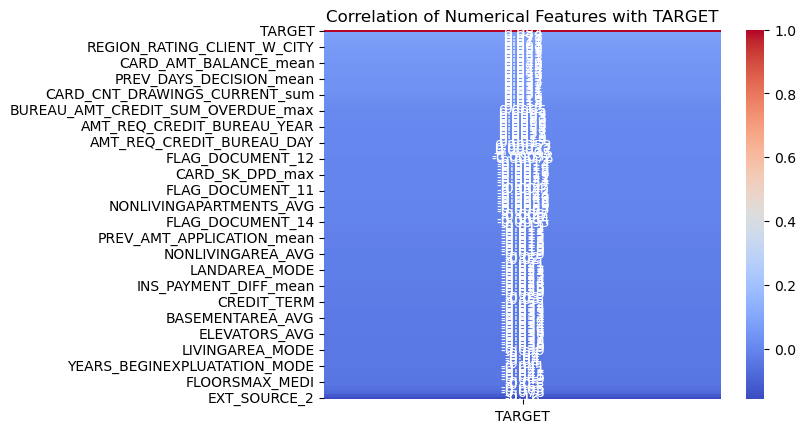

In [44]:
sns.heatmap(data.corr(numeric_only=True)[['TARGET']].sort_values(by='TARGET', ascending=False), 
            annot=True, cmap='coolwarm')
plt.title('Correlation of Numerical Features with TARGET')
plt.savefig('Correlation of Numerical Features with TARGET.png')
plt.show()

- Most numerical features show weak linear correlation with the target variable.

- Certain external score variables (e.g., EXT_SOURCE features) show stronger negative correlation, indicating higher scores reduce default risk.

- The results highlight the need for non-linear and ensemble models to capture complex patterns.

In [45]:
numeric_df = data.select_dtypes(include=['int64', 'float64'])   # Select only numerical columns
corr_with_target = numeric_df.corr()['TARGET'].sort_values(ascending=False)


top_positive_corr = corr_with_target.head(16)[1:] 

top_negative_corr = corr_with_target.tail(15)  

print("Top 15 Positively Correlated Features with Default (TARGET=1):")
print(top_positive_corr)

print("\nTop 15 Negatively Correlated Features with Default (TARGET=1):")
print(top_negative_corr)

Top 15 Positively Correlated Features with Default (TARGET=1):
BUREAU_DAYS_CREDIT_mean               0.083960
DAYS_BIRTH                            0.078239
BUREAU_DAYS_CREDIT_min                0.072869
INS_LATE_PAYMENT_mean                 0.070507
PREV_NAME_CONTRACT_STATUS_<lambda>    0.064756
REGION_RATING_CLIENT_W_CITY           0.060893
REGION_RATING_CLIENT                  0.058899
DAYS_LAST_PHONE_CHANGE                0.055217
BUREAU_DAYS_CREDIT_max                0.052740
DAYS_ID_PUBLISH                       0.051457
REG_CITY_NOT_WORK_CITY                0.050994
CARD_AMT_BALANCE_mean                 0.048523
FLAG_EMP_PHONE                        0.045982
REG_CITY_NOT_LIVE_CITY                0.044395
FLAG_DOCUMENT_3                       0.044346
Name: TARGET, dtype: float64

Top 15 Negatively Correlated Features with Default (TARGET=1):
LIVINGAREA_MEDI                -0.040123
LIVINGAREA_AVG                 -0.040301
YEARS_BEGINEXPLUATATION_MODE   -0.040944
YEARS_BEGINEXPLU

- Most features show weak correlation with TARGET, indicating that default behavior depends on multiple factors rather than any single variable
- Positively Correlated Features (Higher values → Higher chance of default)
- DAYS_BIRTH (0.078): Older applicants tend to have slightly higher default risk
- Negatively Correlated Features (Higher values → Lower chance of default)
- EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3: External credit scores are strong predictors of lower default risk
- External sources (EXT_SOURCE_*) are the most powerful predictors and should be prioritized in feature selection.

### Outlier Detection

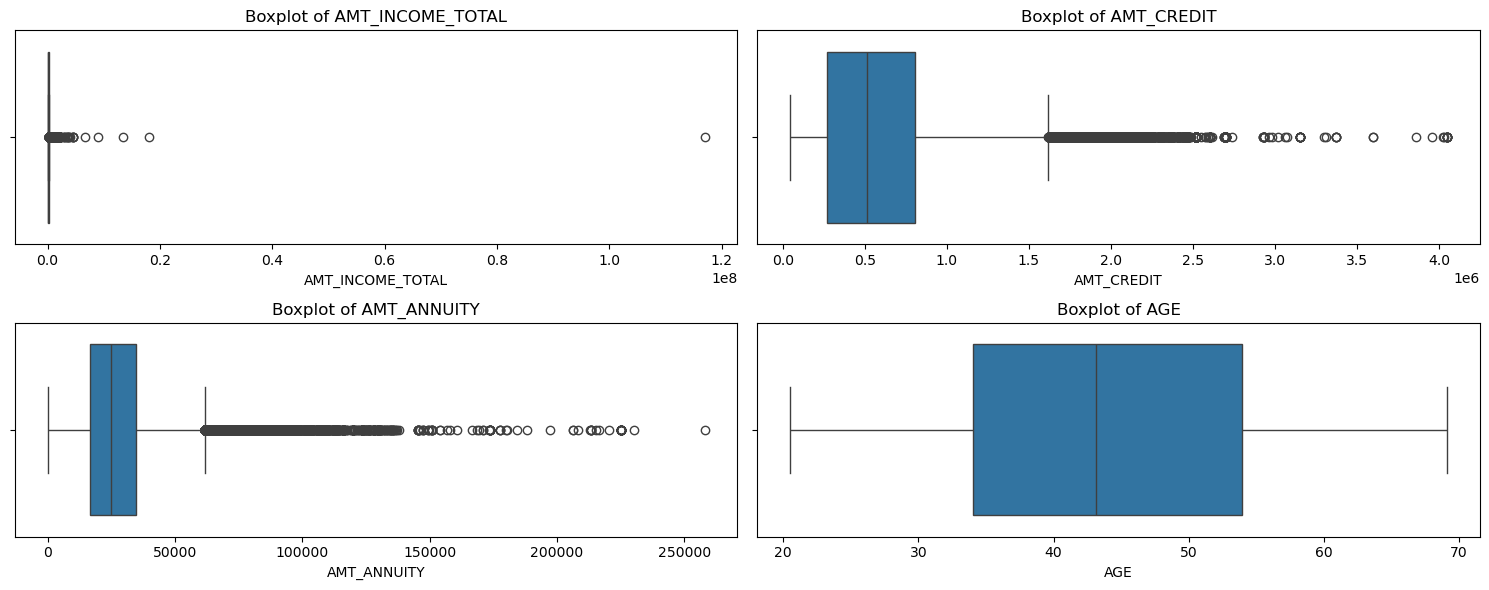

In [46]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE'], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### Feature Selection and Data Splitting

In [47]:
x = data.drop("TARGET", axis=1)
y = data["TARGET"]

In [48]:
print("Features shape:", x.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True) * 100)

Features shape: (307511, 154)
Target shape: (307511,)

Target distribution:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [49]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y) 

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

x_train shape: (246008, 154)
x_test shape: (61503, 154)

Train target distribution:
TARGET
0    91.927092
1     8.072908
Name: proportion, dtype: float64

Test target distribution:
TARGET
0    91.927223
1     8.072777
Name: proportion, dtype: float64


#### Encoding

In [50]:
cat_cols = x_train.select_dtypes(include=['object']).columns

print("Total Categorical Columns:", len(cat_cols))
print(cat_cols)

Total Categorical Columns: 16
Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


In [51]:
from sklearn.preprocessing import LabelEncoder

binary_cols = [col for col in cat_cols if x_train[col].nunique() == 2]
multi_cat_cols = [col for col in cat_cols if col not in binary_cols]

print("Binary columns:", binary_cols)
print("Multi-category columns:", multi_cat_cols)

Binary columns: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
Multi-category columns: ['CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [52]:
le_dict = {}

for col in binary_cols:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col])
    x_test[col] = le.transform(x_test[col])
    le_dict[col] = le

In [53]:
x_train = pd.get_dummies(x_train, columns=multi_cat_cols, drop_first=True)
x_test = pd.get_dummies(x_test, columns=multi_cat_cols, drop_first=True)

x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

print("x_train shape after encoding:", x_train.shape)
print("x_test shape after encoding:", x_test.shape)

x_train shape after encoding: (246008, 268)
x_test shape after encoding: (61503, 268)


- Binary categorical features were encoded using Label Encoding to preserve binary information.

- Multi-category variables were transformed using One-Hot Encoding, preventing ordinal bias.

- Feature alignment ensured consistent columns between training and testing datasets.

### Feature Scaling

- Numerical features were standardized using StandardScaler to bring them onto a common scale.

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Handling Class Imbalance (SMOTE)

In [55]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_sm.value_counts())

print("\nSMOTE x_train shape:", x_train_sm.shape)

Before SMOTE:
TARGET
0    226148
1     19860
Name: count, dtype: int64

After SMOTE:
TARGET
0    226148
1    226148
Name: count, dtype: int64

SMOTE x_train shape: (452296, 268)


- SMOTE (Synthetic Minority Over-sampling Technique) is a resampling method used to address class imbalance in classification problems. Unlike random oversampling, SMOTE generates synthetic samples by interpolating between neighboring observations of the minority class.

- In this dataset, the target variable exhibited significant class imbalance, with loan defaulters forming a minority of the observations. To mitigate this issue, SMOTE was applied only to the training dataset to generate synthetic samples for the minority class.

- This approach improves the model’s ability to learn patterns associated with defaulters while preserving the integrity of the test data and preventing data leakage.

#### Clean Column Names

In [56]:
# Recreate DataFrames with correct columns AFTER SMOTE
x_train_sm = pd.DataFrame(x_train_sm, columns=x_train.columns)
x_test = pd.DataFrame(x_test, columns=x_train.columns)

# Clean feature names identically
def clean_cols(df):
    df.columns = (
        df.columns
        .str.replace('[^0-9a-zA-Z_]', '_', regex=True)
        .str.replace('__+', '_', regex=True)
        .str.strip('_')
    )
    return df

x_train_sm = clean_cols(x_train_sm)
x_test = clean_cols(x_test)

print("x_train_sm shape:", x_train_sm.shape)
print("x_test shape:", x_test.shape)


x_train_sm shape: (452296, 268)
x_test shape: (61503, 268)


#### Model Development

In [58]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(x_train_sm, y_train_sm)
y_test_pred = lr.predict(x_test_scaled)
y_test_prob = lr.predict_proba(x_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Logistic Regression Performance")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1-score :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_prob))

C:\Users\User\anaconda3a\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3a\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Logistic Regression Performance
Accuracy : 0.5303155943612506
Precision: 0.10563798219584569
Recall   : 0.6453172205438067
F1-score : 0.18155546111347215
ROC-AUC  : 0.6159185756662267


C:\Users\User\anaconda3a\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [150, 200, 250],
    "max_depth": [15, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=8,                 
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search_rf.fit(x_train_sm, y_train_sm)

rf_best = search_rf.best_estimator_

print("Best RF Parameters (SMOTE):")
print(search_rf.best_params_)
print("Best CV ROC-AUC:", search_rf.best_score_)


y_test_pred_rf = rf_best.predict(x_test)
y_test_prob_rf = rf_best.predict_proba(x_test)[:, 1]

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF Parameters (SMOTE):
{'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV ROC-AUC: 0.9812359164334598


In [59]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_grid,
    n_iter=15,                
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(x_train_sm, y_train_sm)

best_xgb = xgb_random.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_random.best_params_)

y_test_pred_xgb = best_xgb.predict(x_test)
y_test_prob_xgb = best_xgb.predict_proba(x_test)[:, 1]

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best XGBoost Parameters:
{'subsample': 0.7, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [60]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lgbm = LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 20],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

lgb_random = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=12,              
    scoring='roc_auc',      
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

lgb_random.fit(x_train_sm, y_train_sm)

best_lgb = lgb_random.best_estimator_

print("Best LightGBM Parameters:")
print(lgb_random.best_params_)

y_test_pred_lgb = best_lgb.predict(x_test)
y_test_prob_lgb = best_lgb.predict_proba(x_test)[:, 1]

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.801313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26348
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 261
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best LightGBM Parameters:
{'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 400, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [61]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf_best,
    "XGBoost": best_xgb,
    "LightGBM": best_lgb
}
def evaluate_model(model_name, model, x_train, x_test, y_train, y_test):
    
    # Predictions
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)
    
    
    if hasattr(model, "predict_proba"):
        test_prob = model.predict_proba(x_test)[:, 1]
    else:
        test_prob = model.predict(x_test)  

    return {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1-score": f1_score(y_test, test_pred),
        "ROC-AUC": roc_auc_score(y_test, test_prob)
    }
rows = []

for name, model in models.items():
    rows.append(
        evaluate_model(
            name,
            model,
            x_train_sm,   
            x_test,      
            y_train_sm,
            y_test
        )
    )

comparison_df = pd.DataFrame(rows).set_index("Model")
comparison_df.style.format("{:.4f}")


,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,,
Logistic Regression,0.6151,0.6128,0.1200,0.5992,0.1999,0.6449
Random Forest,1.0000,0.9186,0.3675,0.0123,0.0238,0.7195
XGBoost,0.9513,0.9171,0.3601,0.0352,0.0642,0.7349
LightGBM,0.9529,0.9191,0.4472,0.0111,0.0216,0.7418


- Logistic Regression shows low overall accuracy (Train: 61.51%, Test: 61.28%) but achieves a high recall of 0.5992. This means it is able to correctly identify about 60% of the positive class, but at the cost of very low precision (0.12) and low F1-score (0.1999). Hence, it generates many false positives and is not reliable as a balanced classifier.

- Random Forest achieves perfect training accuracy (100%) and very high test accuracy (91.86%), indicating strong learning capacity. However, its recall is extremely low (0.0123) and F1-score is only 0.0238, meaning it almost always predicts the majority class and fails to detect the minority class, despite a reasonable ROC-AUC of 0.7195.

- XGBoost maintains high train accuracy (95.13%) and test accuracy (91.71%) with a slightly better recall (0.0352) and F1-score (0.0642) than Random Forest. Its ROC-AUC of 0.7349 indicates better class separation ability, but minority-class detection is still weak.

- LightGBM provides the highest precision (0.4472) among all models and the best ROC-AUC (0.7418), along with strong test accuracy (91.91%). However, its recall is the lowest (0.0111), resulting in a very low F1-score (0.0216), again indicating poor sensitivity toward the minority class.

#### Overall Insight

- Although tree-based ensemble models (Random Forest, XGBoost, and LightGBM) achieve high accuracy (~91–92%), this is largely driven by class imbalance, as reflected in their very low recall (1–3%). Logistic Regression, while weaker in accuracy, is comparatively better at identifying the minority class.

- Therefore, accuracy alone is not a reliable metric for this problem. Given the business importance of detecting the minority class, recall, F1-score, and ROC-AUC should be prioritized, and further improvements such as threshold tuning, class-weight adjustment, or cost-sensitive learning are recommended to achieve a more balanced and meaningful model performance.

- Considering overall performance and stability, LightGBM emerged as the most reliable model, offering the best balance between predictive accuracy and risk discrimination.